# Simulation Software:
### Goal:
To successfully test and develop Particle Filter Algorithm.
### Method:
Simulate different phases of a real, model rocket's flight:<br>

## 1. Flight Simulation
**Options to be implemented**: 
- Open Rocket(verified) -> export flight data from the accelerometer
- Custom parabolic flight simulation(not really verified):
  - Simulation of the “Ideal” Acceleration:
    - For the first portion of the flight (thrust phase, defined by t_burn_ratio), the rocket experiences a constant thrust vector (here chosen to be mostly upward with a small horizontal component).
    - After engine cutoff (free‑fall phase), an ideal accelerometer would read zero (0 g) even though the rocket’s position (if you integrated the acceleration) would follow a parabola.
  - Adding Noisy Effects:
    - Vibration Noise: A sinusoid is generated for each axis with a random frequency (15–25 Hz) and phase to mimic the strong high‑frequency vibrations/turbulence.
    - Sensor Noise: White Gaussian noise is added to represent the inherent noise of the sensor.
  - Plotting:
    - The script uses matplotlib to plot each accelerometer channel (X, Y, and Z) versus time. Both the “ideal” (noiseless) and the “measured” (noisy) signals are shown.

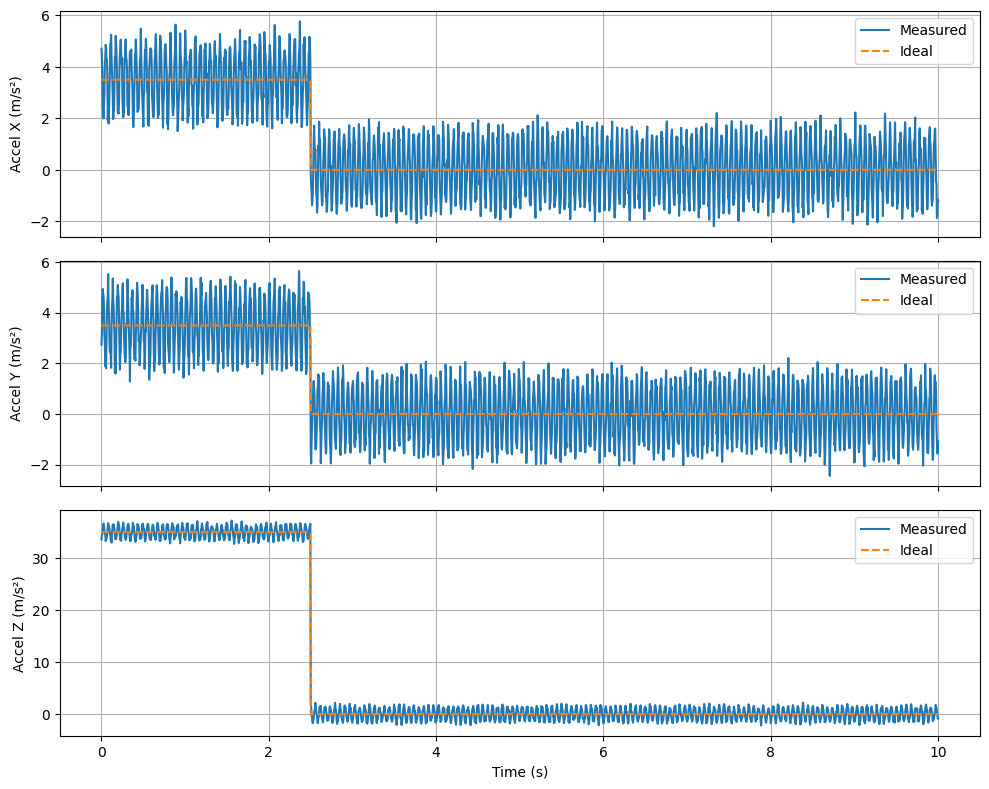

In [2]:
"""
Simulate 3D accelerometer data for a parabolic flight (model rocket)
with realistic noise – just like an MPU9050 would output.
 
The simulation is broken into two phases:
  • Thrust phase (t < t_burn): the rocket fires its engines. In the sensor’s
    body frame the “proper acceleration” is nonzero (roughly, thrust minus gravity).
    (Here we assume the rocket is pointed mostly upward but with a slight horizontal
    component to get a 3D effect.)
  • Free‑fall phase (t >= t_burn): the rocket is on a parabolic (ballistic) trajectory.
    In free‑fall a perfect accelerometer would read zero (i.e. “0‑g”) even though
    integrating the acceleration would yield the parabolic flight path.
 
On top of the “ideal” acceleration we add:
  • High‑frequency sinusoidal vibrations (with random frequency/phase per axis)
  • White Gaussian sensor noise

Adjust the parameters as desired.
"""

import numpy as np
import matplotlib.pyplot as plt
import argparse

def simulate_accelerometer_data(num_steps=1000, dt=0.01, t_burn_ratio=0.2,
                                a_thrust=30.0,
                                sensor_noise_std=0.2,
                                vibration_noise_std=2.0):
    """
    Parameters:
      num_steps (int): Number of time steps.
      dt (float): Duration of each time step [s].
      t_burn_ratio (float): Fraction of total time spent in the thrust phase.
      a_thrust (float): Proper acceleration during the thrust phase (m/s^2).
                        (This is the net acceleration measured by the sensor.)
      sensor_noise_std (float): Standard deviation of white (sensor) noise (m/s^2).
      vibration_noise_std (float): Amplitude of high-frequency vibration noise (m/s^2).
    
    Returns:
      t           : 1D array of time stamps.
      acc_measured: (num_steps x 3) array of simulated accelerometer readings (m/s^2).
      acc_ideal   : (num_steps x 3) array of the underlying “ideal” acceleration.
    
    Note:
      – During the thrust phase (t < t_burn) we assume the rocket’s engines produce a thrust vector.
      – When the engines stop (t >= t_burn) the rocket is in free‑fall. An ideal accelerometer
        would then read 0 (even though integrating 0 gives a parabolic trajectory).
    """
    T = num_steps * dt
    t = np.linspace(0, T, num_steps)
    t_burn = t_burn_ratio * T
    
    # Initialize the ideal acceleration array (3 axes: X, Y, Z)
    acc_ideal = np.zeros((num_steps, 3))
    
    # --- Thrust phase ---
    # Assume the rocket is mostly vertical (Z axis) but with a slight horizontal (X & Y) component.
    # (If you integrated the acceleration, the position in free-fall would follow a parabola.)
    thrust_vector = np.array([0.1 * a_thrust, 0.1 * a_thrust, a_thrust])
    for i, ti in enumerate(t):
        if ti < t_burn:
            acc_ideal[i] = thrust_vector
        else:
            # --- Free-fall phase ---
            # In free-fall the proper acceleration is 0 (i.e. 0 g), even though the integrated
            # position would follow a parabolic trajectory under gravity.
            acc_ideal[i] = np.array([0.0, 0.0, 0.0])
    
    # --- Vibration noise ---
    # Simulate high-frequency sinusoidal vibrations on each axis.
    # We choose a random frequency (in a plausible range) and random phase for each axis.
    freq = np.random.uniform(15, 25, size=3)   # frequencies in Hz for X, Y, Z
    phase = np.random.uniform(0, 2*np.pi, size=3)
    vib_noise = np.zeros((num_steps, 3))
    for axis in range(3):
        vib_noise[:, axis] = vibration_noise_std * np.sin(2 * np.pi * freq[axis] * t + phase[axis])
    
    # --- Sensor noise ---
    # White Gaussian noise simulating the inherent sensor noise.
    sensor_noise = np.random.normal(0, sensor_noise_std, size=(num_steps, 3))
    
    # --- Total measured acceleration ---
    acc_measured = acc_ideal + vib_noise + sensor_noise
    return t, acc_measured, acc_ideal

def main():
    if (False): # Useful only when
        parser = argparse.ArgumentParser(
            description="Simulate 3D accelerometer data for a parabolic flight (model rocket).")
        parser.add_argument("--steps", type=int, default=1000,
                            help="Number of time steps in the simulation (default: 1000)")
        parser.add_argument("--dt", type=float, default=0.01,
                            help="Time step duration in seconds (default: 0.01)")
        parser.add_argument("--t_burn_ratio", type=float, default=0.2,
                            help="Fraction of total time for thrust phase (default: 0.2)")
        parser.add_argument("--a_thrust", type=float, default=30.0,
                            help="Thrust acceleration (m/s^2) during thrust phase (default: 30.0)")
        parser.add_argument("--sensor_noise_std", type=float, default=0.2,
                            help="Sensor noise standard deviation (m/s^2) (default: 0.2)")
        parser.add_argument("--vibration_noise_std", type=float, default=2.0,
                            help="Vibration noise amplitude (m/s^2) (default: 2.0)")
        args = parser.parse_args()
    
        t, acc_measured, acc_ideal = simulate_accelerometer_data(
            num_steps=args.steps,
            dt=args.dt,
            t_burn_ratio=args.t_burn_ratio,
            a_thrust=args.a_thrust,
            sensor_noise_std=args.sensor_noise_std,
            vibration_noise_std=args.vibration_noise_std
        )
    # Realistic sample initialization for the simulation:
    t, acc_measured, acc_ideal = simulate_accelerometer_data(
        num_steps=2000,         # Total number of time steps
        dt=0.005,               # Time step duration in seconds (5 ms)
        t_burn_ratio=0.25,      # 25% of the flight is the thrust phase
        a_thrust=35.0,          # Thrust acceleration (m/s²) during the thrust phase
        sensor_noise_std=0.3,   # Sensor noise standard deviation (m/s²)
        vibration_noise_std=1.5 # Vibration noise amplitude (m/s²)
    )

    
    # --- Plot the simulated accelerometer data ---
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axis_labels = ['X', 'Y', 'Z']
    for i in range(3):
        axs[i].plot(t, acc_measured[:, i], label='Measured', color='C0')
        axs[i].plot(t, acc_ideal[:, i], label='Ideal', color='C1', linestyle='--')
        axs[i].set_ylabel(f"Accel {axis_labels[i]} (m/s²)")
        axs[i].legend()
        axs[i].grid(True)
    axs[2].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


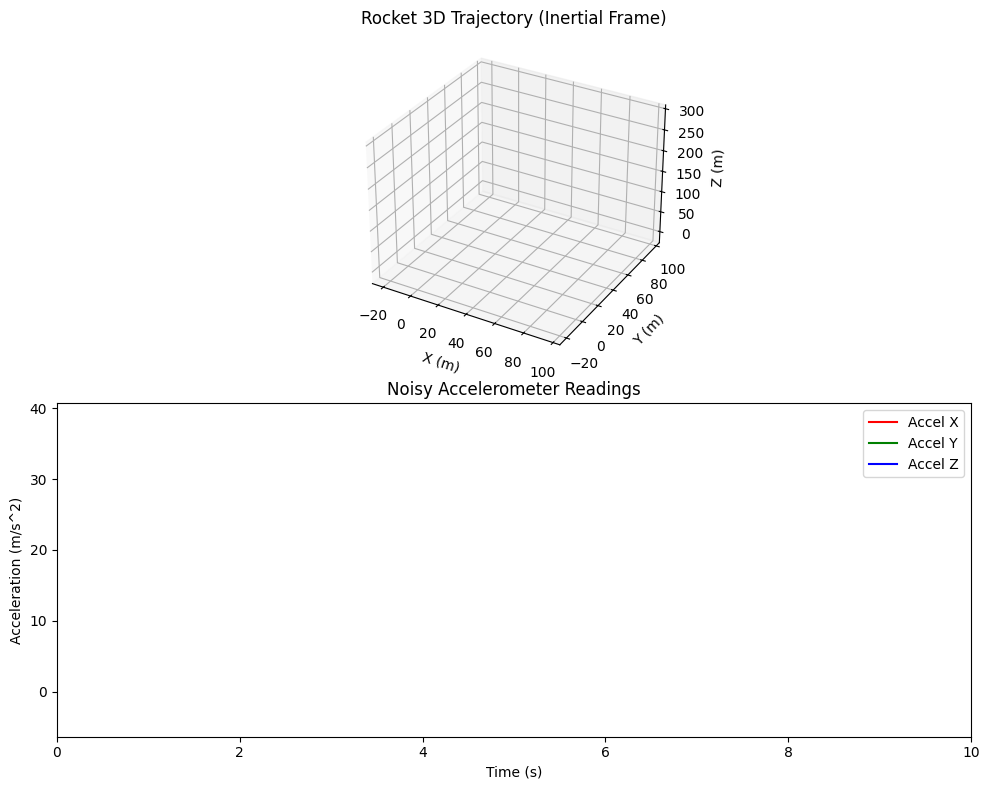

/Users/varunahlawat/Work/GNC_to_moon/personal_fork/GNC_to_the_moon/env/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [3]:
#!/usr/bin/env python3
"""
Simulate and animate 3D accelerometer data for a parabolic (model rocket) flight.
The code does two things:
  1) Generates "proper" accelerometer readings with noise & vibration (like an MPU9050).
  2) Integrates a physical (inertial) acceleration to get a 3D trajectory, then animates it.

Animation:
  - A 3D plot of the rocket's flight path (position in inertial space).
  - A 2D plot of the noisy accelerometer data (X, Y, Z) over time.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def simulate_accelerometer_data(num_steps=1000, dt=0.01, t_burn_ratio=0.2,
                                a_thrust=30.0,
                                sensor_noise_std=0.2,
                                vibration_noise_std=2.0):
    """
    Simulate 3D "proper acceleration" data for a rocket flight.
    
    Proper acceleration is what an ideal accelerometer reads:
      - Thrust phase: constant thrust vector in the rocket frame
      - Free-fall phase: 0 (weightlessness)
      - Add high-frequency vibration noise + white sensor noise
    Returns:
      t            : (num_steps,) array of time
      acc_measured : (num_steps, 3) array of noisy measured accelerations
      acc_ideal    : (num_steps, 3) array of "ideal" (noise-free) accelerations
    """
    T = num_steps * dt
    t = np.linspace(0, T, num_steps)
    t_burn = t_burn_ratio * T
    
    # "Ideal" proper acceleration
    acc_ideal = np.zeros((num_steps, 3))
    
    # Suppose the rocket is mostly vertical with a small horizontal thrust
    # (No gravity here, because in free fall, the rocket "feels" 0 g)
    thrust_vector = np.array([0.1 * a_thrust, 0.1 * a_thrust, a_thrust])
    
    for i, ti in enumerate(t):
        if ti < t_burn:
            acc_ideal[i] = thrust_vector
        else:
            acc_ideal[i] = 0.0  # free-fall => 0 g (ideal)
    
    # High-frequency vibration noise
    freq = np.random.uniform(15, 25, size=3)  # random freq in each axis
    phase = np.random.uniform(0, 2*np.pi, size=3)
    vib_noise = np.zeros_like(acc_ideal)
    for axis in range(3):
        vib_noise[:, axis] = (vibration_noise_std
                              * np.sin(2*np.pi*freq[axis]*t + phase[axis]))
    
    # White sensor noise
    sensor_noise = np.random.normal(0, sensor_noise_std, size=(num_steps, 3))
    
    # Combine everything
    acc_measured = acc_ideal + vib_noise + sensor_noise
    
    return t, acc_measured, acc_ideal

def compute_inertial_trajectory(num_steps, dt, t_burn_ratio, a_thrust):
    """
    Compute the rocket's 3D trajectory in an inertial frame by integrating
    PHYSICAL acceleration (including gravity).
    
    This is separate from the 'proper' acceleration read by the accelerometer.
    
    We'll assume:
      - During thrust: net inertial acceleration = [0.1*a_thrust, 0.1*a_thrust, a_thrust - g]
      - After thrust:  free-fall => [0, 0, -g]
    Returns:
      pos : (num_steps, 3) array of position in 3D
    """
    g = 9.81
    T = num_steps * dt
    t = np.linspace(0, T, num_steps)
    t_burn = t_burn_ratio * T
    
    acc_inertial = np.zeros((num_steps, 3))
    thrust_vector_inertial = np.array([0.1*a_thrust, 0.1*a_thrust, a_thrust - g])
    freefall_vector_inertial = np.array([0.0, 0.0, -g])
    
    for i, ti in enumerate(t):
        if ti < t_burn:
            acc_inertial[i] = thrust_vector_inertial
        else:
            acc_inertial[i] = freefall_vector_inertial
    
    # Integrate to get velocity and position (simple Euler)
    vel = np.zeros((num_steps, 3))
    pos = np.zeros((num_steps, 3))
    
    for i in range(num_steps - 1):
        vel[i+1] = vel[i] + acc_inertial[i]*dt
        pos[i+1] = pos[i] + vel[i]*dt
    
    return pos

def main():
    # Simulation parameters
    num_steps = 2000
    dt = 0.005          # 5 ms
    t_burn_ratio = 0.25 # 25% thrust phase
    a_thrust = 35.0     # thrust acceleration (m/s^2)
    
    # Noise parameters
    sensor_noise_std = 0.3
    vibration_noise_std = 1.5
    
    # 1) Generate the accelerometer data
    t, acc_measured, acc_ideal = simulate_accelerometer_data(
        num_steps=num_steps,
        dt=dt,
        t_burn_ratio=t_burn_ratio,
        a_thrust=a_thrust,
        sensor_noise_std=sensor_noise_std,
        vibration_noise_std=vibration_noise_std
    )
    
    # 2) Compute the rocket's 3D position in inertial space (for plotting the trajectory)
    pos = compute_inertial_trajectory(num_steps, dt, t_burn_ratio, a_thrust)
    
    # -------------------------------------------------------------------------
    # Set up the figure and axes for animation
    fig = plt.figure(figsize=(10, 8))
    
    # Upper subplot: 3D trajectory
    ax3d = fig.add_subplot(2, 1, 1, projection='3d')
    ax3d.set_title("Rocket 3D Trajectory (Inertial Frame)")
    ax3d.set_xlabel("X (m)")
    ax3d.set_ylabel("Y (m)")
    ax3d.set_zlabel("Z (m)")
    
    # We'll define a line object for the trajectory
    line3d, = ax3d.plot([], [], [], 'o-', color='red', label='Trajectory')
    
    # Lower subplot: 2D acceleration vs time
    ax2d = fig.add_subplot(2, 1, 2)
    ax2d.set_title("Noisy Accelerometer Readings")
    ax2d.set_xlabel("Time (s)")
    ax2d.set_ylabel("Acceleration (m/s^2)")
    
    # Lines for X, Y, Z
    lineX, = ax2d.plot([], [], color='r', label='Accel X')
    lineY, = ax2d.plot([], [], color='g', label='Accel Y')
    lineZ, = ax2d.plot([], [], color='b', label='Accel Z')
    ax2d.legend(loc='upper right')
    
    # Pre-set the axis limits based on the data
    # 3D axes:
    x_min, x_max = np.min(pos[:,0]), np.max(pos[:,0])
    y_min, y_max = np.min(pos[:,1]), np.max(pos[:,1])
    z_min, z_max = np.min(pos[:,2]), np.max(pos[:,2])
    # Make a little margin
    margin_3d = 0.1 * max(abs(x_min), abs(x_max),
                          abs(y_min), abs(y_max),
                          abs(z_min), abs(z_max), 1.0)
    ax3d.set_xlim3d([x_min - margin_3d, x_max + margin_3d])
    ax3d.set_ylim3d([y_min - margin_3d, y_max + margin_3d])
    ax3d.set_zlim3d([z_min - margin_3d, z_max + margin_3d])
    
    # 2D acceleration axis:
    T = t[-1]  # total sim time
    ax2d.set_xlim(0, T)
    # For Y-limits, find min and max of the entire measured data
    acc_min, acc_max = np.min(acc_measured), np.max(acc_measured)
    margin_2d = 0.1 * max(abs(acc_min), abs(acc_max), 1.0)
    ax2d.set_ylim(acc_min - margin_2d, acc_max + margin_2d)
    
    # -------------------------------------------------------------------------
    # Animation update functions
    
    def init_anim():
        # 3D line
        line3d.set_data([], [])
        line3d.set_3d_properties([])
        # 2D lines
        lineX.set_data([], [])
        lineY.set_data([], [])
        lineZ.set_data([], [])
        return line3d, lineX, lineY, lineZ
    
    def update(frame):
        # frame goes from 0..num_steps-1
        # 3D line: show rocket position from 0..frame
        line3d.set_data(pos[:frame, 0], pos[:frame, 1])
        line3d.set_3d_properties(pos[:frame, 2])
        
        # 2D lines: show acceleration from 0..frame
        lineX.set_data(t[:frame], acc_measured[:frame, 0])
        lineY.set_data(t[:frame], acc_measured[:frame, 1])
        lineZ.set_data(t[:frame], acc_measured[:frame, 2])
        
        return line3d, lineX, lineY, lineZ
    
    # Create the animation
    interval_ms = dt * 1000  # real-time based on dt
    ani = FuncAnimation(
        fig, update, frames=num_steps,
        init_func=init_anim, interval=interval_ms, blit=False
    )
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()


## 2. GPS Simulation for a given flight

## 3. Flight Simulation for a given flight